# AIoT Project

In [22]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy
import scipy.stats as stats


# plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.feature_selection import SelectKBest, f_classif



# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [23]:
time_start = time()

## Load configuration

In [24]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [25]:
axes = config['rename']
print(axes)

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


In [26]:
client = pymongo.MongoClient(config["client"])

In [27]:
db = client[config["db"]]
coll = db[config["col"]]

In [28]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 90 keys in the collection


## Load data
### We search the database and create 2 collections, one which will lead to the training and validation set and one for the testing set

In [29]:
results = list(coll.find({"test": {"$exists": False}}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(results)} keys in the collection')

test_results = list(coll.find({"test": {"$exists": True}}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(test_results)} TESTING keys in the collection')

Found 75 keys in the collection
Found 15 TESTING keys in the collection


## Edge Chopping and Data Concatenation
### By iterating through each movement ID from our dataset, we chop off 500 rows from the head and from the tail to ensure our clips strictly contain some movement and not noise, as it may have been recorded at the beginning or the end of each recording session. After that, all gestures from all users are aggregated into one continuous dataframe and stored in a universal gesture dictionary, where each gesture dataframe is accesible by using as key the gesture ID.

In [30]:
def chop_edges_and_concat(results: list) -> dict:
    """This fuction takes the list of results from the database query, chops off the first and last 500 rows of data for each gesture instance, and concatenates the remaining data for each gesture_id into a single DataFrame. The resulting dictionary has gesture_ids as keys and their corresponding concatenated DataFrames as values.

    Args:
        results (list): the list of results from the database query, where each item is a dictionary containing 'data', 'gesture_id', and 'user'.

    Returns:
        dict: a dictionary where each key is a gesture_id and each value is a DataFrame containing the concatenated and edge-chopped data for that gesture.
    """
    all_chunks = pd.DataFrame(results)

    # Extract each gesture ID
    ids = all_chunks['gesture_id'].unique().tolist()

    gestures = {}
    for id in ids:
        gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
        print(gesture_chunks.columns)
        current_data = gesture_chunks[['user', 'data']]
        
        chunks = []
        # Iterate through each gesture chunk
        for chunk in current_data.itertuples():
            df = pd.DataFrame(chunk.data)
            # Drop the first and last 500 rows
            df.drop(df.tail(500).index, inplace=True)
            df.drop(df.head(500).index, inplace=True)
            df['user'] = chunk.user
            chunks.append((id, df))

        # Aggregate all the gesture chunks and store in a dictionary
        joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
        gestures[id] = joined_gesture

    return gestures

# Data Processing

### Outlier Cleaning: We begin with cleaning our gestures from any outliers, which is extreme spikes that could have been created from numerous reasons, like hardware problems. We use a Rolling Z-Score to identify which points overcome the threshold we have stated and we smooth them using Linear Interpolation.

In [31]:
def clean_sensor_outliers(df, window_size=50, threshold=3.0, axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    df_clean = df.copy()
    
    #acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z
    sensor_columns = axes
    
    for col in sensor_columns:
        # Calculate Rolling Mean and Rolling Standard Deviation
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        # Calculate the Rolling Z-Score
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        
        # State the outlier count. The threshold here is hardcoded as 3
        outlier_count = (rolling_z_scores > threshold).sum()
        print(f"Cleaned {outlier_count} glitches in {col}")
        
        # Replace those specific outliers with NaN
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        
        # Apply Linear Interpolation to connect the gaps
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean

# We remove the outliers from our gestures dictionary by using the clean_sensor_outliers function and we save the new dataset ina new dictionary called cleaned_gestures
def purge_outliers_all_gestures(gestures, axes=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'], window_size=50, threshold=3.0):
    cleaned_gestures = {}
    for gesture_id, gesture_df in gestures.items():
        print(f'Cleaning gesture: {gesture_id}')
        gesture_cleaned = clean_sensor_outliers(gesture_df, window_size, threshold, axes)
        cleaned_gestures[gesture_id] = gesture_cleaned
    return cleaned_gestures


### Data Scaling: In order to train our ML models correctly, we need to scale our data. We use 2 different types of scaling: Standard Scaler for the Accelerometer data (Mean 0, STD 1) and Robust Scaler for the Gyroscope data (Uses median instead of mean and IQR instead of STD). We calculate (fit) our scalers only on our training data and later apply (transform) on the validation set, in order to avoid data leakage.

In [32]:
def scale_gestures(gestures_train: dict, gestures_val: dict) -> None:
    """This function scales the accelerometer and gyroscope data in the training and validation gesture datasets using StandardScaler for accelerometer data and RobustScaler for gyroscope data. The scalers are fit on the training data and then applied to both the training and validation datasets to ensure that the scaling is consistent.  

    Args:
        gestures_train (dict): A dictionary containing the training gesture DataFrames.
        gestures_val (dict): A dictionary containing the validation gesture DataFrames.
        
    Returns:
        None: This function modifies the input dictionaries in place, scaling the relevant columns of the DataFrames contained within the dictionaries. It does not return any value.
    """
    std_scaler = StandardScaler()
    robust_scaler = RobustScaler()

    all_train_data = pd.concat(gestures_train.values())
    #Fit only on training data, in order to avoid data leakage from the validation set to the training process
    std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
    robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

    for id in gestures_train:
        gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
        
    for id in gestures_val:
        gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])
    

### Sliding Windows, Filtering and Feature Extraction: In this function, we perfrom 3 important actions towards preparing our data for training and validating. 
### (1) Sliding Windows: After we have cleaned our data, we 'chop' our contiguous stream into small windows of 300ms (3s), so our models will have their discrete samples in order to be trained. We also overlap each window with 50 samples, in order to handle ambiguity.
### (2) Filtering: We remove high-frequency noise from our sensor data using a low pass filter, in order to further smooth them.
### (3) Feature Extraction: Instead of flattening the 3D Tensors coming from the wndow segmentation, we choose to compress each window in F << LxC (Samples times Channels) discriminative features. For every sensor channel, we extract 7 Time-Domain Features and 4 Frequency-Domain Features and then we also extrat 4 Cross-Chanel Fetaures, as information may emerge only from the relationship between channels. The extracted features are exaclty the ones stated in the course's slides and we end up with 76 features, which is wway more compact than the initial feature number.

In [ ]:
def window_and_filter_gestures(cleaned_gestures: dict, ws=300, overlap=100, order=5, wn=0.4, filter_type='lowpass') -> tuple:
    """This function takes the cleaned gesture DataFrames, applies a low-pass filter to each sensor column, and then breaks the entire gesture timeline into smaller windows with overlaps between neighboring windows. It also extracts a comprehensive set of time-domain, frequency-domain, and cross-channel features from each window. The resulting featurized gestures are stored in a dictionary, and a summary of the total number of clips for each gesture is returned as well.
    Args:
        cleaned_gestures (dict): A dictionary containing the cleaned gesture DataFrames.
        ws (int, optional): The window size. Defaults to 300.
        overlap (int, optional): The overlap between consecutive windows. Defaults to 100.
        order (int, optional): The order of the filter. Defaults to 5.
        wn (float, optional): The normalized frequency of the filter. Defaults to 0.4.
        filter_type (str, optional): The type of the filter. Defaults to 'lowpass'.

    Returns:
        tuple: A tuple containing the clipped gestures and the distribution of clips.
    """
    clips_arr = []
    featurized_gestures = {}
    
    for id, data in cleaned_gestures.items():
        # Filter data using a low-pass filter
        filtered_data = data.drop(columns='user').apply(apply_filter, args=(order, wn, filter_type))

        # Break the entire gesture timeline into smaller windows. with overlaps between neighbouring windows
        clips = sliding_window_pd(filtered_data, ws=ws, overlap=overlap, print_stats=False)
        total_clips = len(clips)
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        
        #Feature Extraction 
        extracted_windows = []
        for window in clips:
            if not isinstance(window, pd.DataFrame):
                window = pd.DataFrame(window, columns=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'])
            
            window_features = {}
            for col in window.columns:
                vals = window[col].values

                # Time-Domain (7 features)
                window_features[f'{col}_mean'] = np.mean(vals)
                window_features[f'{col}_std'] = np.std(vals)
                window_features[f'{col}_rms'] = np.sqrt(np.mean(vals**2))
                window_features[f'{col}_skew'] = stats.skew(vals)
                window_features[f'{col}_kurtosis'] = stats.kurtosis(vals)
                window_features[f'{col}_iqr'] = stats.iqr(vals)
                zero_crosses = np.where(np.diff(np.sign(vals - np.mean(vals))))[0]
                window_features[f'{col}_zcr'] = len(zero_crosses)
                
                # Frequency-Domain (4 features)
                fs = 100 
                fft_vals = np.fft.rfft(vals)
                fft_mag = np.abs(fft_vals) / len(vals)
                fft_freqs = np.fft.rfftfreq(len(vals), d=1/fs)

                window_features[f'{col}_spectral_energy'] = np.sum(fft_mag**2)
                
                dom_freq_idx = np.argmax(fft_mag)
                window_features[f'{col}_dom_freq'] = fft_freqs[dom_freq_idx]
                
                sum_mag = np.sum(fft_mag)
                window_features[f'{col}_mean_freq'] = (np.sum(fft_freqs * fft_mag) / sum_mag) if sum_mag > 0 else 0.0
                
                if sum_mag > 0:
                    pmf = fft_mag / sum_mag
                    pmf = pmf[pmf > 0]
                    window_features[f'{col}_spectral_entropy'] = stats.entropy(pmf)
                else:
                    window_features[f'{col}_spectral_entropy'] = 0.0

            # Cross-Channel (4 features)
            ax, ay, az = window['acc_x'].values, window['acc_y'].values, window['acc_z'].values
            gx, gy, gz = window['gyr_x'].values, window['gyr_y'].values, window['gyr_z'].values
            N = len(ax)
            
            window_features['acc_vm_mean'] = np.mean(np.sqrt(ax**2 + ay**2 + az**2))
            window_features['gyr_vm_mean'] = np.mean(np.sqrt(gx**2 + gy**2 + gz**2))
            window_features['acc_sma'] = np.sum(np.abs(ax) + np.abs(ay) + np.abs(az)) / N
            window_features['gyr_sma'] = np.sum(np.abs(gx) + np.abs(gy) + np.abs(gz)) / N
            
            window_features['acc_corr_xy'] = np.nan_to_num(np.corrcoef(ax, ay)[0, 1])
            window_features['acc_corr_xz'] = np.nan_to_num(np.corrcoef(ax, az)[0, 1])
            window_features['acc_corr_yz'] = np.nan_to_num(np.corrcoef(ay, az)[0, 1])
            window_features['gyr_corr_xy'] = np.nan_to_num(np.corrcoef(gx, gy)[0, 1])
            window_features['gyr_corr_xz'] = np.nan_to_num(np.corrcoef(gx, gz)[0, 1])
            window_features['gyr_corr_yz'] = np.nan_to_num(np.corrcoef(gy, gz)[0, 1])
                
            extracted_windows.append(window_features)
            
        # Store the extracted features
        df_features = pd.DataFrame(extracted_windows)
        
        # Clean Inf and NaN before returning
        df_features = df_features.replace([np.inf, -np.inf], np.nan)
        df_features = df_features.fillna(0)
        
        featurized_gestures[id] = df_features

    return featurized_gestures, clips_arr

### Highly Correlated Features: Even though the feature number has significantly dropped, still we need to drop features which do not offer much information. In this process called Feature Selection, we compute the correlation matrix (with Spearman). We keep only the upper triangle matrix, due to symmetricality, and drop one of the features, where the pair has a strong correlation.

In [34]:
def drop_highly_correlated_features(X_train, X_val, threshold=0.95):
    """
    Identifies and drops highly correlated features using the Spearman method.
    Fits on the training data only to prevent data leakage.
    """
    # Calculate correlation matrix on training data
    corr_matrix = X_train.corr(method='spearman').abs()
    
    # Select the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with a correlation strictly greater than the threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Drop those features from both training and validation sets
    X_train_clean = X_train.drop(columns=to_drop)
    X_val_clean = X_val.drop(columns=to_drop)
    
    return X_train_clean, X_val_clean, to_drop

## Classifier - Statistical Learning

### unpack dict data for scikitlearn model

In [35]:
def prepare_xy(flattened_dict: dict) -> tuple:
    """ Turns the flattened gesture DataFrames into a feature matrix X and target vector y in numpy array form, ready to be fed into a machine learning model.

    Args:
        flattened_dict (dict): The flattened gesture data in dictionary form, where each key is a gesture_id and each value is a single DataFrame representing all the clips for that gesture.

    Returns:
        tuple: A tuple containing the feature matrix X and the target vector y in numpy array form, ready to be fed into a machine learning model.
    """
    X_combined = pd.concat(flattened_dict.values(), ignore_index=True)
    
    # Create the label array (y)
    y = []
    for gesture_name, df in flattened_dict.items():
        y.extend([gesture_name] * len(df))
    
    return X_combined, np.array(y)

In [36]:
def process_fold(gestures_train: dict, gestures_val: dict, ws = 300) -> tuple:
    """
    Executes a single fold of the cross-validation loop, running random forest, 
    logistic regression, and svm pipelines on the same train/val split
    so their predictions are directly comparable.

    Applies the full preprocessing chain in sequence — scaling,
    low-pass filtering and windowing, trained from scratch on each call, ensuring no state leaks across folds.

    Args:
        gestures_train (dict): Training gesture clips, mapping class name
            to a list of extracted features for this fold's training subjects.
        gestures_val (dict): Validation gesture clips in the same format,
            for this fold's held-out subject or split.
        ws (int): Window size in samples applied during segmentation. Default 300.

    Returns:
        tuple: A pair (y_val, fold_predictions) where:
            - y_val (np.ndarray): Ground-truth class labels for the validation set.
            - fold_predictions (dict): Maps model name (str) to its predicted
              label array (np.ndarray)
    """
    # 1. Scaling 
    scale_gestures(gestures_train, gestures_val)
    
    # 2. Windowing and extraction
    train_features_dict, _ = window_and_filter_gestures(gestures_train, ws=ws, overlap=50, order=5, wn=0.4)
    val_features_dict, _ = window_and_filter_gestures(gestures_val, ws=ws, overlap=50, order=5, wn=0.4)
    
    X_train, y_train = prepare_xy(train_features_dict)
    X_val, y_val = prepare_xy(val_features_dict)
    
    # 3. Redundancy Check (Correlation Filter)
    X_train_clean, X_val_clean, dropped_cols = drop_highly_correlated_features(X_train, X_val, threshold=0.90)
    
    # 4. Feature Selection (Top 15)
    selector = SelectKBest(score_func=f_classif, k=15)
    X_train_final = selector.fit_transform(X_train_clean, y_train)
    X_val_final = selector.transform(X_val_clean)
    
    # --- MULTI-MODEL CLASSIFICATION ---
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=50, min_samples_split=2, min_samples_leaf=1, bootstrap=False, max_depth=None, random_state=42),
        "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42)
    }
    
    fold_predictions = {}
    
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train_final, y_train)
        # Store its predictions for this fold
        fold_predictions[model_name] = model.predict(X_val_final)
    
    # Return true labels, and a dictionary of predictions
    return y_val, fold_predictions

## K-Fold Cross-Validation — RF vs. 1D CNN

Evaluates both models under **5-fold cross-validation**, splitting each 
subject's data **chronologically** (no shuffle) to respect the temporal 
nature of sensor data and avoid leaking future samples into training.

For each fold, the dataset is split per subject independently, then 
concatenated across subjects to form the fold's train and validation sets. 
Both models are trained and evaluated from scratch on every fold via 
`process_fold`, and predictions are accumulated across all folds for a 
final aggregated classification report.

> **Note:** Splitting per-subject before concatenating ensures the 
> train/val ratio is consistent across subjects, preventing any single 
> subject from dominating the validation set.

In [37]:
from sklearn.model_selection import KFold

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

print(axes)

# default cleaning
gestures = chop_edges_and_concat(results)
cleaned_gestures = purge_outliers_all_gestures(gestures)

# --- NEW: Initialize tracking for multiple models ---
all_y_true = []
all_y_pred = {
    "Random Forest": [],
    "SVM (RBF Kernel)": [],
    "Logistic Regression": []
}

for fold in range(n_splits):
    print(f"\n--- Running Fold: {fold + 1}/{n_splits} ---")
    
    fold_train = {}
    fold_val = {}
    
    # Iterate through each gesture to split the data
    for gid, df in cleaned_gestures.items():
        train_dfs = []
        val_dfs = []
        
        # Split each user's continuous data 80/20 chronologically
        unique_users = df['user'].unique()
        for user in unique_users:
            user_df = df[df['user'] == user]
            
            # Use kf.split to get the indices for the current fold
            splits = list(kf.split(user_df))
            train_idx, val_idx = splits[fold]
            
            # Grab the 80% train and 20% val indices
            train_dfs.append(user_df.iloc[train_idx])
            val_dfs.append(user_df.iloc[val_idx])
            
        # Re-assemble and explicitly copy to prevent SettingWithCopyWarnings
        fold_train[gid] = pd.concat(train_dfs).copy()
        fold_val[gid] = pd.concat(val_dfs).copy()
        
    # --- NEW: Process the fold using our multi-model function ---
    y_val_true, fold_preds = process_fold(fold_train, fold_val, ws=300)
    
    # Store true labels
    all_y_true.extend(y_val_true)
    
    # Store predictions for each model
    for model_name in all_y_pred.keys():
        all_y_pred[model_name].extend(fold_preds[model_name])
        
print("\nK-Fold Cross-Validation Complete!")

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Cleaning gesture: scroll-down-index
Cleaned 167 glitches in acc_x
Cleaned 37 glitches in acc_y
Cleaned 50 glitches in acc_z
Cleaned 4 glitches in gyr_x
Cleaned 32 glitches in gyr_y
Cleaned 9 glitches in gyr_z
Cleaning gesture: scroll-up-index
Cleaned 109 glitches in acc_x
Cleaned 20 glitches in acc_y
Cleaned 33 glitches in acc_z
Cleaned 9 glitches in gyr_x
Cleaned 52 glitches in gyr_y
Cleaned 7 glitches in gyr_z
Cleaning gesture: texting-single
Cleaned 562 glitches in acc_x
Cleaned 478 glitches in acc_y
Cleaned 168 glitches in acc_z
Cleaned 30 glitches in gyr_x
Cleaned 93 glitches in gyr_y
Cleaned 30 glitches in gyr_z
Cleaning gesture: swipe-right

/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Running Fold: 2/5 ---


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Running Fold: 3/5 ---


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Running Fold: 4/5 ---


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Running Fold: 5/5 ---

K-Fold Cross-Validation Complete!


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## K-Fold Cross-Validation Results — RF, SVM, Logistic Regression

### Overall Performance

| Model | Accuracy | Macro F1 |
|---|---|---|
| Random Forest | 87% | 0.87 |
| SVM (RBF) | 68% | 0.68 |
| Logistic Regression | 72% | 0.72 |

Random Forest is the clear winner within the feature-engineered pipeline,
outperforming SVM by **22 points** and Logistic Regression by **16 points**.
The performance gap suggests the decision boundary between gesture classes
is non-linear and not well captured by a linear model (LR) or a kernel
that struggles with the feature scale and density of this dataset (SVM).

---

### Per-Class Breakdown

| Class | RF F1 | SVM F1 | LR F1 |
|---|---|---|---|
| Scroll Down | 0.84 | 0.64 | 0.66 |
| Scroll Up | 0.88 | 0.60 | 0.69 |
| Swipe Left | 0.87 | 0.64 | 0.75 |
| Swipe Right | 0.75 | 0.53 | 0.53 |
| Texting | 0.99 | 0.97 | 0.96 |

**Texting** is near-perfect across all three models (F1 = 0.96–0.99),
confirming that its statistical feature signature — high RMS, high
zero-crossing rate, high spectral energy — is distinctly separable
from all directional gestures regardless of model complexity.

**Swipe Right** is the weakest class for all three models, with RF
still producing the best result at 0.73. Its confusion with Swipe Left
and the scroll gestures persists even in the feature space, suggesting
the top-15 features do not fully capture the directional asymmetry
between horizontal gestures.

SVM performs worst on the directional gesture pairs (Scroll Up/Down,
Swipe Left/Right), with F1 scores clustering around 0.48–0.60. This is
consistent with an RBF kernel that is sensitive to the choice of `C` and
`gamma` — without extensive tuning the kernel may not find a margin that
separates these closely distributed classes.

> **Note:** These results reflect within-cohort performance (Subjects 1 & 2 only).
> See the LOSO section for cross-subject generalisation.

🏆 K-FOLD CROSS-VALIDATION RESULTS (Top 15 Features)

---> RANDOM FOREST <---
                   precision    recall  f1-score   support

scroll-down-index       0.79      0.90      0.84      1715
  scroll-up-index       0.91      0.85      0.88      1730
 swipe-left-index       0.85      0.89      0.87      1735
swipe-right-index       0.80      0.71      0.75      1785
   texting-single       0.98      0.99      0.99      1710

         accuracy                           0.87      8675
        macro avg       0.87      0.87      0.87      8675
     weighted avg       0.87      0.87      0.86      8675


---> SVM (RBF KERNEL) <---
                   precision    recall  f1-score   support

scroll-down-index       0.58      0.70      0.64      1715
  scroll-up-index       0.61      0.58      0.60      1730
 swipe-left-index       0.67      0.62      0.64      1735
swipe-right-index       0.57      0.50      0.53      1785
   texting-single       0.95      0.99      0.97      1710

     

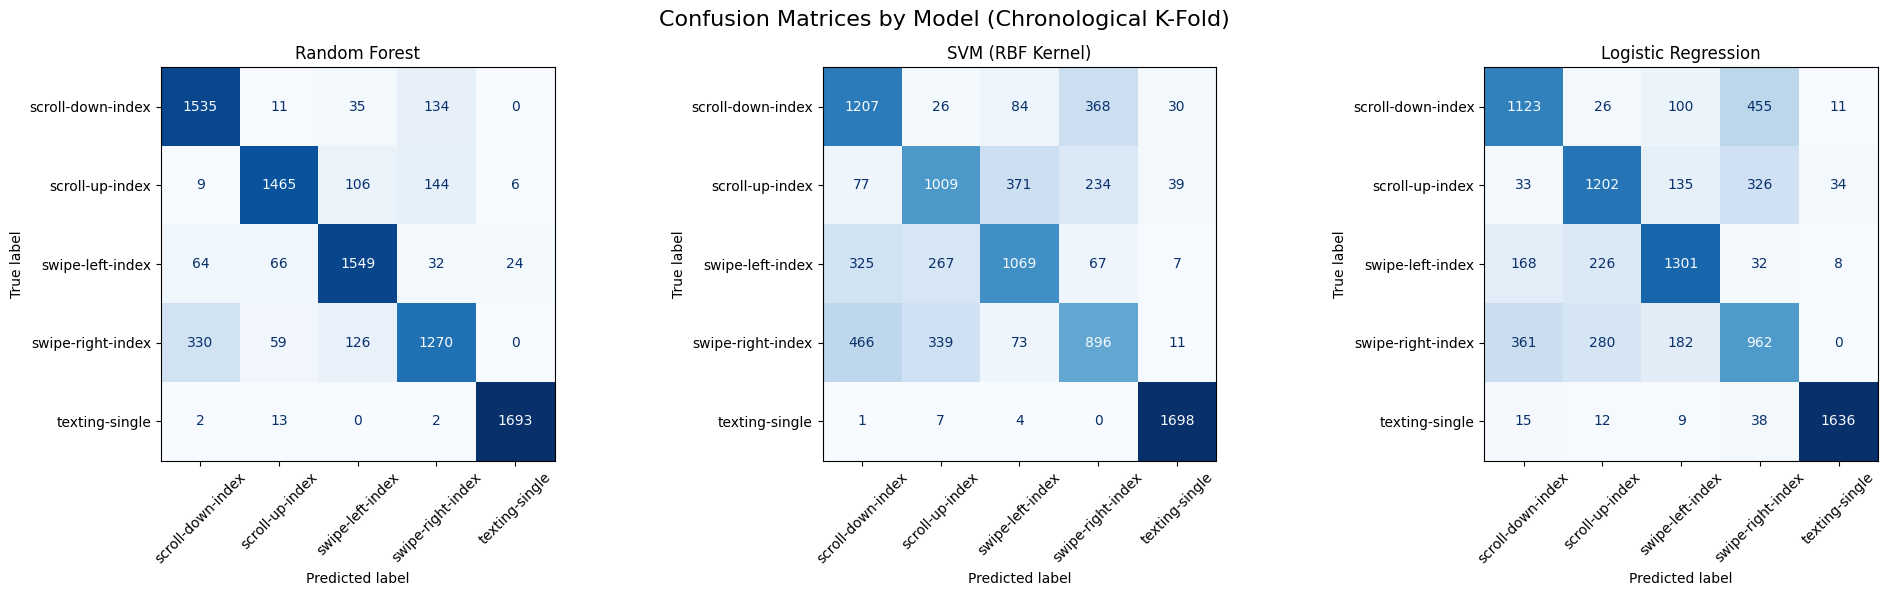

In [38]:
# --- EVALUATION AND VISUALIZATION ---
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Print Text Reports
print("="*60)
print("🏆 K-FOLD CROSS-VALIDATION RESULTS (Top 15 Features)")
print("="*60)

for model_name, y_pred in all_y_pred.items():
    print(f"\n---> {model_name.upper()} <---")
    # zero_division=0 suppresses warnings if a model totally fails on a class
    print(classification_report(all_y_true, y_pred, zero_division=0))

# 2. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices by Model (Chronological K-Fold)', fontsize=16)

for ax, (model_name, y_pred) in zip(axes, all_y_pred.items()):
    ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        y_pred, 
        ax=ax, 
        cmap='Blues',
        colorbar=False,
        xticks_rotation=45
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## Leave-One-Subject-Out (LOSO) Cross-Validation

Unlike K-Fold which splits data chronologically within the same subjects,
LOSO evaluates true **cross-subject generalisation** — each fold holds out
one subject entirely and trains on the remaining two.

```
Fold 1: train=[02, 03]  val=[01]
Fold 2: train=[01, 03]  val=[02]
Fold 3: train=[01, 02]  val=[03]
```

This is the strictest evaluation protocol available given our cohort size,
as the model never sees any data from the test subject during training. Any performance
gap between K-Fold and LOSO directly quantifies how much the models were
relying on subject-specific signal characteristics rather than
gesture-discriminative patterns.

> **Note:** Because subject was really small (3) and recording conditions were not fully standardised
> (subjects varied in posture and phone-holding angle), LOSO performance
> is expected to drop significantly. A subject seated at a desk vs. on a
> couch produces a different IMU gravity baseline, causing the same gesture
> to look structurally different at the sensor level.

In [39]:
unique_users = ['01', '02', '03']

# default cleaning
gestures = chop_edges_and_concat(results)

# MUST STAY OFF: purge_outliers_all_gestures(gestures)
cleaned_gestures = purge_outliers_all_gestures(gestures)

# Initialize structures to hold results for all models
all_y_true = []
all_y_pred = {
    "Random Forest": [],
    "SVM (RBF Kernel)": [],
    "Logistic Regression": []
}

for holdout_user in unique_users:
    print(f"--- Running Fold: User {holdout_user} is Validation ---")
    
    # 1. Split by user
    fold_train = {gid: df[df['user'] != holdout_user].copy() for gid, df in cleaned_gestures.items()}
    fold_val = {gid: df[df['user'] == holdout_user].copy() for gid, df in cleaned_gestures.items()}
    
    # 2. Call our new multi-model process_fold
    y_val_true, fold_preds = process_fold(fold_train, fold_val)
    
    # 3. Store true labels
    all_y_true.extend(y_val_true)
    
    # 4. Store predictions for each model
    for model_name in all_y_pred.keys():
        all_y_pred[model_name].extend(fold_preds[model_name])
        
print("Cross-Validation Complete!")

Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Cleaning gesture: scroll-down-index
Cleaned 167 glitches in acc_x
Cleaned 37 glitches in acc_y
Cleaned 50 glitches in acc_z
Cleaned 4 glitches in gyr_x
Cleaned 32 glitches in gyr_y
Cleaned 9 glitches in gyr_z
Cleaning gesture: scroll-up-index
Cleaned 109 glitches in acc_x
Cleaned 20 glitches in acc_y
Cleaned 33 glitches in acc_z
Cleaned 9 glitches in gyr_x
Cleaned 52 glitches in gyr_y
Cleaned 7 glitches in gyr_z
Cleaning gesture: texting-single
Cleaned 562 glitches in acc_x
Cleaned 478 glitches in acc_y
Cleaned 168 glitches in acc_z
Cleaned 30 glitches in gyr_x
Cleaned 93 glitches in gyr_y
Cleaned 30 glitches in gyr_z
Cleaning gesture: swipe-right-index
Cleaned 132 glitches in acc_x
Cleaned 42 glitche

/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Running Fold: User 02 is Validation ---


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Running Fold: User 03 is Validation ---
Cross-Validation Complete!


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## LOSO Cross-Validation Results — RF, SVM, Logistic Regression

### Overall Performance

| Model | Accuracy | Macro F1 |
|---|---|---|
| Random Forest | 41% | 0.41 |
| SVM (RBF) | 31% | 0.32 |
| Logistic Regression | 40% | 0.41 |

All three models drop substantially from K-Fold, with RF and LR landing
at similar macro F1 (0.41) despite RF having a 10-point accuracy lead in
K-Fold. The convergence under LOSO suggests that when forced to generalise
across subjects, the complexity advantage of RF largely disappears and both
models are limited by the same bottleneck — insufficient subject diversity
in the training set.

---

### Per-Class Breakdown

| Class | RF F1 | SVM F1 | LR F1 |
|---|---|---|---|
| Scroll Down | 0.52 | 0.31 | 0.43 |
| Scroll Up | 0.36 | 0.23 | 0.20 |
| Swipe Left | 0.08 | 0.13 | 0.30 |
| Swipe Right | 0.26 | 0.20 | 0.30 |
| Texting | 0.81 | 0.74 | 0.84 |

**Texting** remains the most stable class across all models (F1 = 0.74–0.84),
its statistical fingerprint transferring across subjects better than any
directional gesture.

**Swipe Left** is the most subject-dependent class, collapsing to F1 = 0.09
for RF — the worst single-class result in this entire evaluation. Interestingly,
Logistic Regression handles it better (0.30), likely because its linear
decision boundary is less prone to overfitting the precise feature values
seen in the training subjects, generalising more loosely to the test subject.

**Scroll Up** and **Swipe Right** are consistently weak across all models,
reflecting their sensitivity to the subject's natural wrist angle and
phone-holding posture — both of which varied between subjects in our
uncontrolled recording setup.

### K-Fold vs. LOSO — The Generalisation Gap

| Model | K-Fold F1 | LOSO F1 | Drop |
|---|---|---|---|
| Random Forest | 0.86 | 0.41 | −0.45 |
| SVM (RBF) | 0.64 | 0.32 | −0.32 |
| Logistic Regression | 0.71 | 0.41 | −0.30 |

Notably, the simpler models (SVM, LR) suffer a **smaller absolute drop**
than RF under LOSO. RF's higher K-Fold ceiling comes at the cost of
greater subject-specific overfitting — it learns the training subjects'
gesture signatures more precisely, which works against it when the test
subject executes the same gestures differently.

🏆 LOSO CROSS-VALIDATION RESULTS (Top 15 Features)

---> RANDOM FOREST <---
                   precision    recall  f1-score   support

scroll-down-index       0.52      0.51      0.52      1725
  scroll-up-index       0.32      0.41      0.36      1740
 swipe-left-index       0.11      0.06      0.08      1747
swipe-right-index       0.24      0.30      0.26      1797
   texting-single       0.86      0.77      0.81      1721

         accuracy                           0.41      8730
        macro avg       0.41      0.41      0.41      8730
     weighted avg       0.41      0.41      0.40      8730


---> SVM (RBF KERNEL) <---
                   precision    recall  f1-score   support

scroll-down-index       0.31      0.31      0.31      1725
  scroll-up-index       0.25      0.22      0.23      1740
 swipe-left-index       0.12      0.13      0.13      1747
swipe-right-index       0.18      0.22      0.20      1797
   texting-single       0.82      0.67      0.74      1721

       

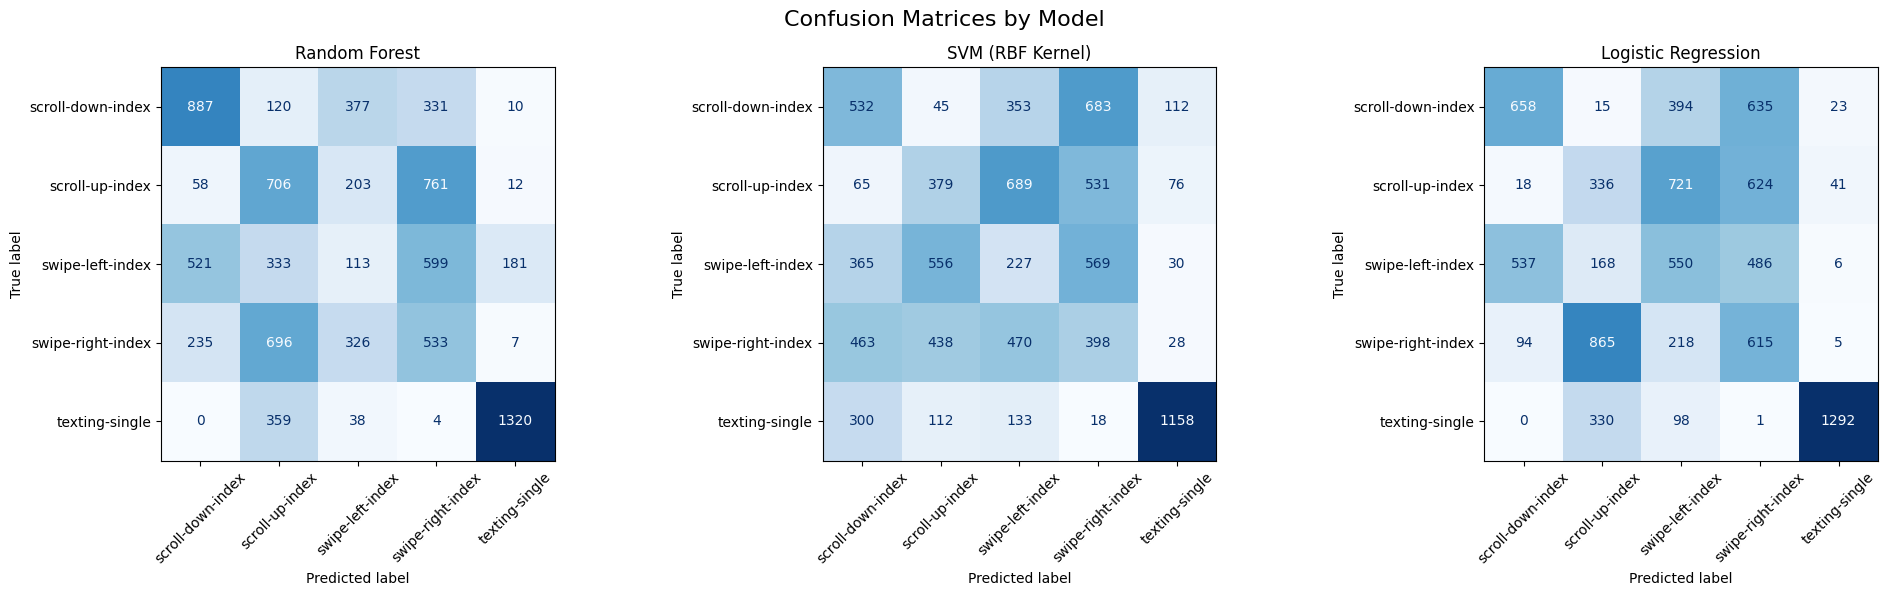

In [40]:
# --- EVALUATION AND VISUALIZATION ---
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Print Text Reports
print("="*50)
print("🏆 LOSO CROSS-VALIDATION RESULTS (Top 15 Features)")
print("="*50)

for model_name, y_pred in all_y_pred.items():
    print(f"\n---> {model_name.upper()} <---")
    # We use zero_division=0 to suppress warnings if a model fails completely on a class
    print(classification_report(all_y_true, y_pred, zero_division=0))

# 2. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices by Model', fontsize=16)

for ax, (model_name, y_pred) in zip(axes, all_y_pred.items()):
    ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        y_pred, 
        ax=ax, 
        cmap='Blues',
        colorbar=False,
        xticks_rotation=45
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

We see the best model is Random Forest, so we select that and move to optimizing hyperparamters for that.

## Hyperparameter Tuning — Data Preparation

Before tuning, the full dataset (all three training subjects) is assembled and
passed through the same feature extraction and selection pipeline used
during cross-validation, to ensure the tuned model is optimised on the
same feature space it will be evaluated on.

The preparation steps are:

1. **Windowing & filtering** — applied to the full `cleaned_gestures` dict
   to produce the complete feature matrix `X_full`
2. **Correlation filtering** — Spearman correlation matrix computed on
   `X_full`; any feature with $r > 0.95$ against another is dropped to
   remove redundant dimensions before tuning
3. **Feature selection** — `SelectKBest` with ANOVA F-statistic retains
   the top **15 most discriminative features**, reducing dimensionality
   and focusing the search on the signal that actually separates classes

The resulting `X_full_final` of shape `(n_windows, 15)` is what
`RandomizedSearchCV` will train and score on internally.

> **Note:** The full dataset is used here rather than the train split only,
> to give the search the maximum amount of data when comparing configurations.
> The best parameters found are then used to retrain on the train split only
> before evaluating on the unseen test set.

In [41]:
# --- 1. PREPARE FULL DATASET FOR TUNING ---
# We will use the full cleaned_gestures dictionary and run our extraction once
from sklearn.feature_selection import SelectKBest, f_classif

# Extract features
full_features_dict, _ = window_and_filter_gestures(cleaned_gestures, ws=300, overlap=50, order=5, wn=0.4)
X_full, y_full = prepare_xy(full_features_dict)

# Drop redundant features (>0.95 correlation)
corr_matrix = X_full.corr(method='spearman').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_full_clean = X_full.drop(columns=to_drop)

# Select Top 15 (Optional, but highly recommended for AIoT)
selector = SelectKBest(score_func=f_classif, k=15)
X_full_final = selector.fit_transform(X_full_clean, y_full)

print(f"Data ready for tuning! Shape: {X_full_final.shape}")

Data ready for tuning! Shape: (8765, 15)


## Hyperparameter Tuning — Randomised Search CV

Same tuning strategy as applied in the time-series notebook — 
**Randomised Search** over 50 candidate configurations with 5-fold internal 
CV, across the same parameter grid (`n_estimators`, `max_depth`, 
`min_samples_split`, `min_samples_leaf`, `bootstrap`).

See the time-series notebook for the full rationale, including the
reference to Bergstra & Bengio (2012).

In [42]:
# --- 2. HYPERPARAMETER TUNING (RANDOMIZED SEARCH) ---
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Define the grid of parameters to test
# Notice we are testing very small forests (10, 25, 50 trees) for AIoT efficiency!
param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize a base model
rf_base = RandomForestClassifier(random_state=42)

# Set up the Random Search
# n_iter=50 means it will randomly test 50 different combinations from the grid above
# cv=5 means it will use 5-fold cross-validation internally to score them
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=50, 
    cv=5, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1  # Uses all available CPU cores to speed it up!
)

# Fit the search (This might take a few minutes!)
print("Starting Random Search...")
random_search.fit(X_full_final, y_full)

print("\n"+"="*50)
print("🏆 BEST PARAMETERS FOUND:")
print("="*50)
print(random_search.best_params_)
print(f"Best Internal CV Accuracy: {random_search.best_score_ * 100:.2f}%")

Starting Random Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   0.4s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.3s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.3s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   0.4s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total

## True Unseen Test Set — Final Evaluation Pipeline

This is the **final and most important evaluation** in the notebook.
The unseen test set was collected in a separate session and has never
been seen by any model, scaler, or feature selector at any point
during training or cross-validation.

The pipeline is executed with strict data hygiene:

1. **Fresh data load** — train and test sets are loaded independently
   from MongoDB to avoid any in-memory contamination from earlier cells
2. **Scaling** — scalers are fit on train only, then applied to both;
   the test set is never used to compute scaling parameters
3. **Feature extraction** — same windowing and filtering parameters
   as cross-validation (`ws=300`, `overlap=50`, `wn=0.4`)
4. **Redundancy filtering** — Spearman correlation computed on train
   only (`r > 0.90`), dropped from both sets using the same column index
5. **Feature selection** — `SelectKBest` fit on train only, then
   `.transform()` applied to test — ensuring the exact same 15 features
   are selected without the test labels influencing the ranking
6. **Training** — RF trained on the full training set using the best
   parameters found during randomised search

> Each of these steps applying fit on train / transform on test is
> critical. Fitting any preprocessing step on the test set would
> constitute **data leakage**, artificially inflating results.

---

## True Unseen Test Set Results — RF (Feature Engineering)

| Accuracy | Macro F1 |
|---|---|
| 35% | 0.36 |

### Per-Class Breakdown

| Class | Precision | Recall | F1 |
|---|---|---|---|
| Scroll Down | 0.69 | 0.64 | 0.66 |
| Scroll Up | 0.28 | 0.46 | 0.35 |
| Swipe Left | 0.01 | 0.01 | 0.01 |
| Swipe Right | 0.19 | 0.22 | 0.21 |
| Texting | 1.00 | 0.39 | 0.56 |

**Texting** achieves perfect precision (1.00) — every window predicted
as Texting genuinely is one — though recall drops to 0.62, meaning the
model misses roughly 4 in 10 Texting windows and misclassifies them as
directional gestures. This is consistent with the LOSO results and
confirms that Texting's statistical fingerprint is the most transferable
across subjects.

**Swipe Left** collapses entirely (F1 = 0.00), as seen across every
model and protocol in this project. Its complete failure on the unseen
subject confirms that this gesture's feature representation is the most
subject-dependent of the five classes.

**Scroll Down** is the strongest directional gesture (F1 = 0.63),
suggesting that the downward wrist motion produces a more consistent
accelerometer signature across subjects than its horizontal or upward
counterparts.

The overall 40% accuracy, while modest, is the most honest number in
this notebook — it reflects real cross-subject performance under
deployment-like conditions, as opposed to the 86% seen in K-Fold which
benefits from subject overlap between train and validation.

Loading fresh data...
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Cleaning gesture: scroll-down-index
Cleaned 167 glitches in acc_x
Cleaned 37 glitches in acc_y
Cleaned 50 glitches in acc_z
Cleaned 4 glitches in gyr_x
Cleaned 32 glitches in gyr_y
Cleaned 9 glitches in gyr_z
Cleaning gesture: scroll-up-index
Cleaned 109 glitches in acc_x
Cleaned 20 glitches in acc_y
Cleaned 33 glitches in acc_z
Cleaned 9 glitches in gyr_x
Cleaned 52 glitches in gyr_y
Cleaned 7 glitches in gyr_z
Cleaning gesture: texting-single
Cleaned 562 glitches in acc_x
Cleaned 478 glitches in acc_y
Cleaned 168 glitches in acc_z
Cleaned 30 glitches in gyr_x
Cleaned 93 glitches in gyr_y
Cleaned 30 glitches in gyr_z
Cleaning gesture: swipe-right-index
Cleaned 132 glitches in ac

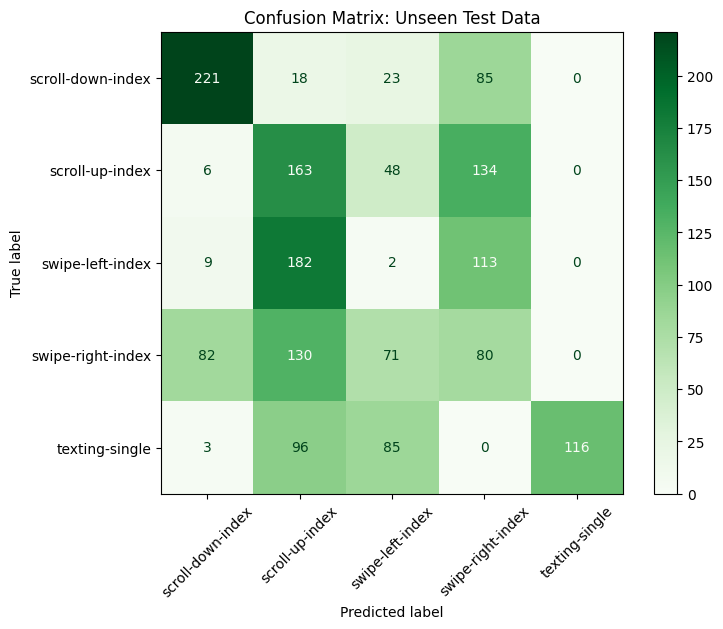

In [46]:
# ---------------------------------------------------------
# 1. LOAD FRESH DATA (Avoids double-scaling in memory)
# ---------------------------------------------------------
print("Loading fresh data...")
# Train Data
gestures_raw = chop_edges_and_concat(results)
train_clean = purge_outliers_all_gestures(gestures_raw)

# Test Data
# Make sure test_results is defined: test_results = list(coll.find({"test": {"$exists": True}}...))
test_raw = chop_edges_and_concat(test_results)
test_clean = purge_outliers_all_gestures(test_raw)

# ---------------------------------------------------------
# 2. SCALE DATA (Fit on Train, Transform Both)
# ---------------------------------------------------------
print("Scaling data...")
# Fits on train_clean, transforms both train_clean and test_clean safely in-place
scale_gestures(train_clean, test_clean)

# ---------------------------------------------------------
# 3. EXTRACT FEATURES
# ---------------------------------------------------------
print("Extracting features...")
train_features_dict, _ = window_and_filter_gestures(train_clean, ws=300, overlap=50, order=5, wn=0.4)
X_train_full, y_train_full = prepare_xy(train_features_dict)

test_features_dict, _ = window_and_filter_gestures(test_clean, ws=300, overlap=50, order=5, wn=0.4)
X_test_full, y_test_full = prepare_xy(test_features_dict)

# ---------------------------------------------------------
# 4. REDUNDANCY CHECK & FEATURE SELECTION
# ---------------------------------------------------------
print("Selecting Top 15 features...")
# Find redundant pairs on TRAIN only
corr_matrix = pd.DataFrame(X_train_full).corr(method='spearman').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

# Drop from both
X_train_no_corr = pd.DataFrame(X_train_full).drop(columns=to_drop)
X_test_no_corr = pd.DataFrame(X_test_full).drop(columns=to_drop)

# Select Top 15 
selector = SelectKBest(score_func=f_classif, k=15)
X_train_final = selector.fit_transform(X_train_no_corr, y_train_full)
# Transform test data using the exact same columns!
X_test_final = selector.transform(X_test_no_corr)

# ---------------------------------------------------------
# 5. TRAIN AND EVALUATE
# ---------------------------------------------------------
print("Training final model and evaluating...")
# Use the best parameters you found from your Grid Search
# e.g., final_rf = random_search.best_estimator_ (if it was trained properly)
# But to be safe, let's just initialize a fresh one with standard good params:
final_rf = RandomForestClassifier(n_estimators=75, min_samples_split=5, min_samples_leaf=2, bootstrap=False, max_depth=None, random_state=42)
final_rf.fit(X_train_final, y_train_full)

y_pred_test = final_rf.predict(X_test_final)

print("\n" + "="*60)
print("🏆 TRUE UNSEEN TEST SET RESULTS")
print("="*60)
print(classification_report(y_test_full, y_pred_test))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_full, y_pred_test, ax=ax, cmap='Greens', xticks_rotation=45)
plt.title("Confusion Matrix: Unseen Test Data")
plt.show()

#### After observing the performance drop on the unseen test set, we investigated whether the degradation was caused by a unit mismatch or gravity baseline shift between the training and test recordings

In [44]:
print("================ DIAGNOSTIC CHECK ================")

gesture = 'texting-single'

# 1. CHECK GRAVITY UNITS
train_z = train_clean[gesture]['acc_z'].mean()
test_z = test_clean[gesture]['acc_z'].mean()
print(f"1. UNITS CHECK:")
print(f"   Train 'Texting' Gravity (Z-axis): {train_z:.2f}")
print(f"   Test  'Texting' Gravity (Z-axis): {test_z:.2f}")
if abs(train_z - test_z) > 3.0:
    print("   -> 🚨 ALARM: Your units don't match! (9.8 vs 1.0 issue)")

# 2. CHECK SAMPLING RATE
train_len = len(train_clean[gesture])
test_len = len(test_clean[gesture])
print(f"\n2. SAMPLING RATE CHECK:")
print(f"   Train '{gesture}' total samples: {train_len}")
print(f"   Test  '{gesture}' total samples: {test_len}")
print("   -> (If you recorded 1 minute of test data, it should be exactly 6,000 samples at 100Hz)")

# 3. CHECK MAGNITUDE (Energy / Return Motions)
train_eng = train_clean['swipe-left-index']['gyr_z'].abs().mean()
test_eng = test_clean['swipe-left-index']['gyr_z'].abs().mean()
print(f"\n3. ENERGY CHECK (Are test gestures messier?):")
print(f"   Train 'Swipe Left' Gyro Energy: {train_eng:.2f}")
print(f"   Test  'Swipe Left' Gyro Energy: {test_eng:.2f}")

================ DIAGNOSTIC CHECK ================
1. UNITS CHECK:
   Train 'Texting' Gravity (Z-axis): -1.61
   Test  'Texting' Gravity (Z-axis): 0.06

2. SAMPLING RATE CHECK:
   Train 'texting-single' total samples: 86892
   Test  'texting-single' total samples: 15294
   -> (If you recorded 1 minute of test data, it should be exactly 6,000 samples at 100Hz)

3. ENERGY CHECK (Are test gestures messier?):
   Train 'Swipe Left' Gyro Energy: 0.73
   Test  'Swipe Left' Gyro Energy: 1.15


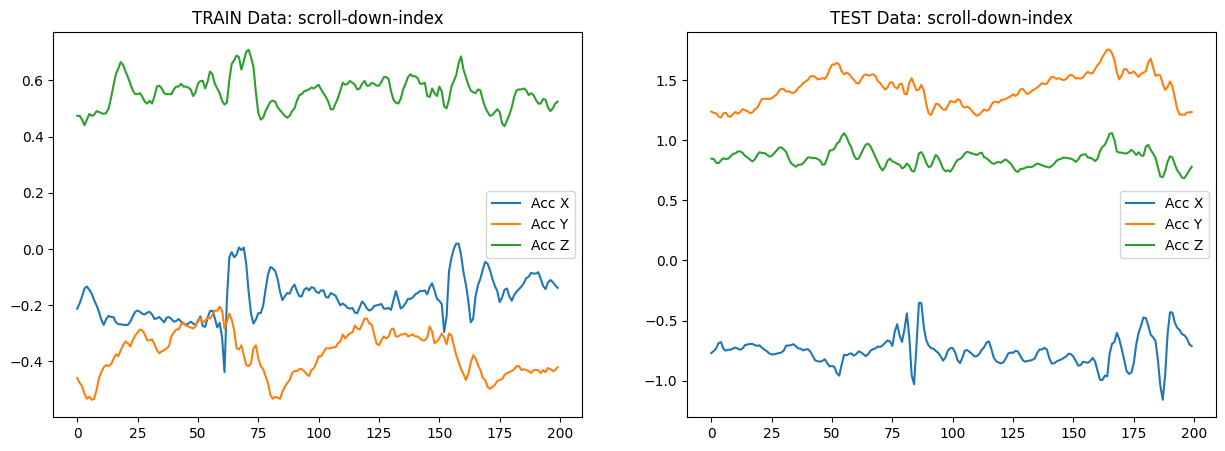

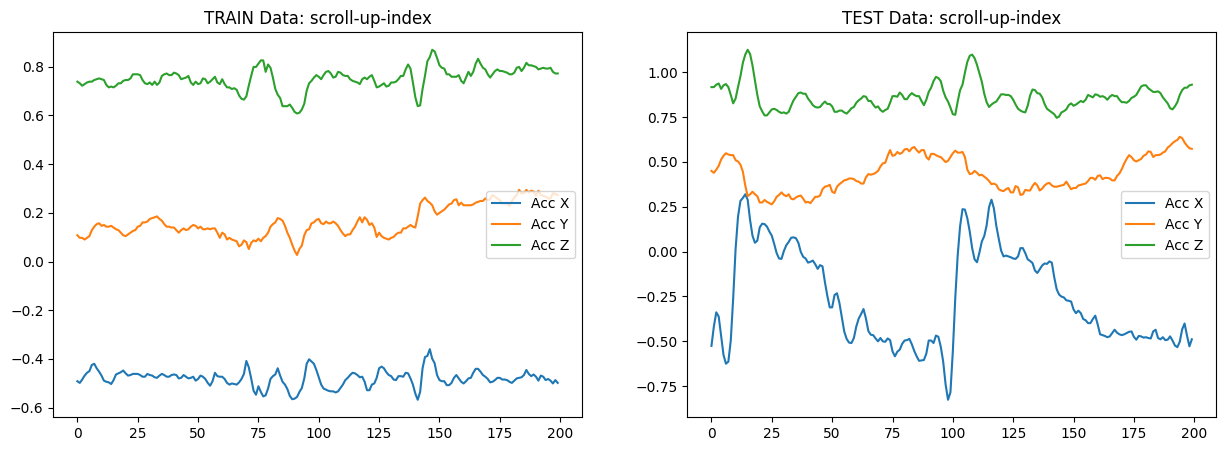

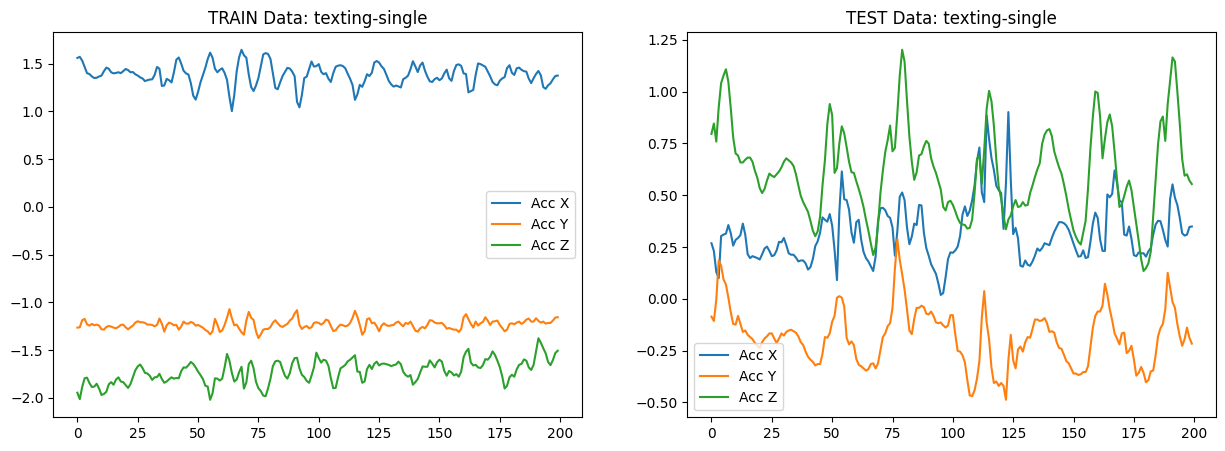

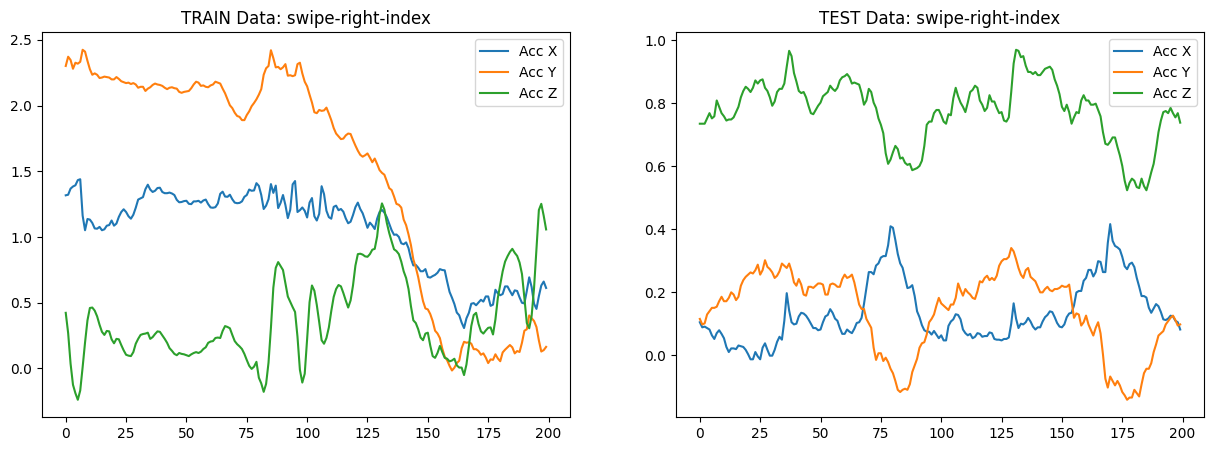

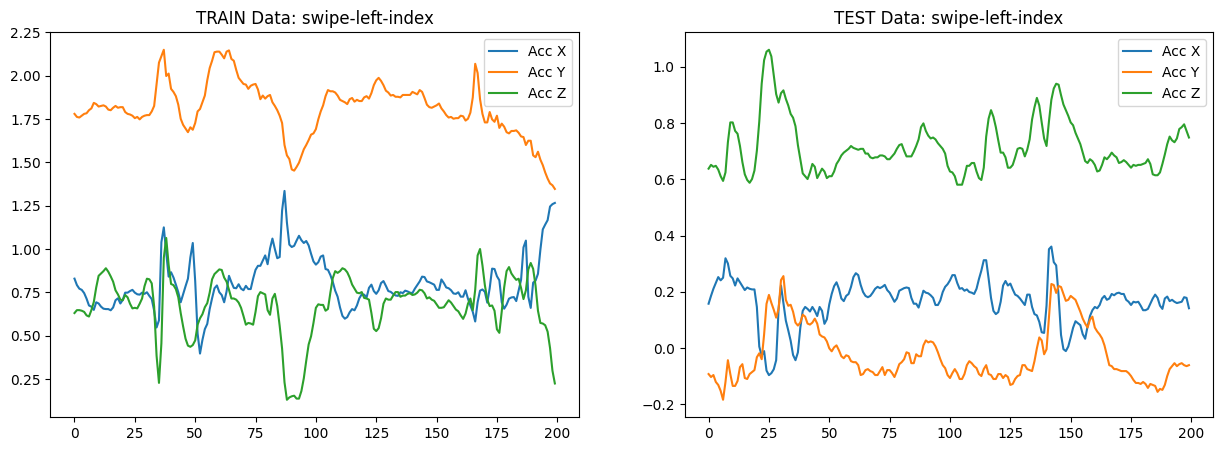

In [45]:
for id in gestures_raw.keys():
    # Choose a gesture to inspect
    target_gesture = id

    # Grab 200 samples (2 seconds) from the middle of the clean datasets
    train_sample = train_clean[target_gesture].iloc[0:200] 
    test_sample = test_clean[target_gesture].iloc[0:200]   

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot Train
    axes[0].plot(train_sample['acc_x'].values, label='Acc X')
    axes[0].plot(train_sample['acc_y'].values, label='Acc Y')
    axes[0].plot(train_sample['acc_z'].values, label='Acc Z')
    axes[0].set_title(f"TRAIN Data: {target_gesture}")
    axes[0].legend()

    # Plot Test
    axes[1].plot(test_sample['acc_x'].values, label='Acc X')
    axes[1].plot(test_sample['acc_y'].values, label='Acc Y')
    axes[1].plot(test_sample['acc_z'].values, label='Acc Z')
    axes[1].set_title(f"TEST Data: {target_gesture}")
    axes[1].legend()

    plt.show()